# 04 — Visual exploration of the honeypot mechanism

Companion notebook to [`03-honeypots-retroactives.md`](03-honeypots-retroactives.md) (v0.1).

Three questions explored visually, without a full simulator:

1. **Detection of a cheater**: how fast does `f̂` cross a "deactivation" threshold (`f̂ < 0.80`) as a function of `φ` and `w_h`?
2. **Trajectories**: `f̂(t)` of an honest agent vs a cheater over 200 validations under different `(φ, w_h)` configurations.
3. **Cold-start**: with soft routing `φ_cold-start(j) = max(φ, 1 − j/n_init)`, what does cold-start exit look like for an honest agent, a mediocre, and a cheater?

All values (`α₀=19, β₀=1, φ=0.10, w_h=5, n_init=20`) are the spec defaults, marked `[TO CALIBRATE]`.

## §0 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ALPHA0, BETA0 = 19.0, 1.0  # Beta(19, 1) prior
PHI_DEFAULT = 0.10
W_H_DEFAULT = 5.0
N_INIT_DEFAULT = 20

RNG = np.random.default_rng(42)

## §1 — Speed of detection of a cheater

**Theoretical model.** An agent whose true reliability rate is `p_true = 1 − θ_cheat` (where `θ_cheat` is its error probability) performs `n` validations of which a fraction `φ` are honeypots. Each incorrect honeypot adds `w_h` to `β`, each incorrect normal task adds 1.

The expectation of `f̂` after `n` validations is:
$$\mathbb{E}[\hat f(n)] = \frac{\alpha_0 + (1-\theta_{\text{cheat}}) \cdot n_{\text{eff}}}{\alpha_0 + \beta_0 + n_{\text{eff}}}, \qquad n_{\text{eff}}(n,\phi,w_h) = n \cdot ((1-\phi) + \phi \cdot w_h)$$

We define **detection** as the moment when `f̂` crosses 0.80 (threshold below which `M(f, d=0.1) ≈ 0` with the default sigmoid, cf. `01-formules-mathematiques.md` §C). We solve for `n_eff` then for `n`:
$$n_{\text{detect}}(\theta_{\text{cheat}}, \phi, w_h) = \frac{3}{\theta_{\text{cheat}} - 0.20} \cdot \frac{1}{(1-\phi) + \phi \cdot w_h}$$

(defined for `θ_cheat > 0.20`; otherwise `f̂` never drops to 0.80).

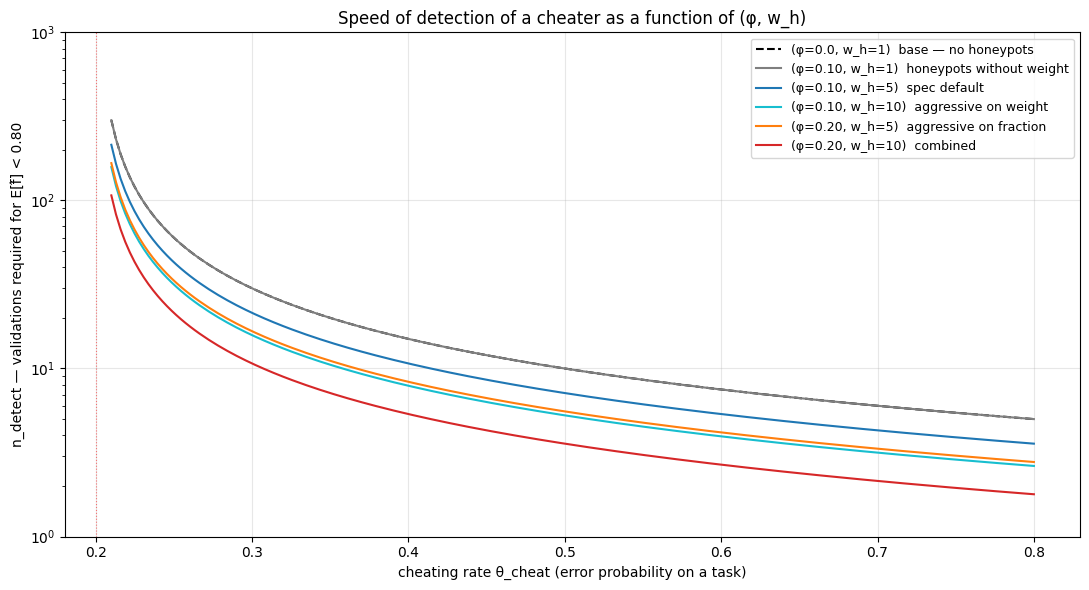

In [2]:
def n_detect(theta_cheat, phi, w_h, threshold=0.80, alpha0=ALPHA0, beta0=BETA0):
    """Number of validations for E[f̂] to drop below threshold.
    Returns np.inf if the cheater does not cheat enough to cross the threshold.
    """
    # E[f̂] = (alpha0 + (1-theta)*n_eff) / (alpha0 + beta0 + n_eff) = threshold
    # => alpha0 + (1-theta)*n_eff = threshold*(alpha0+beta0) + threshold*n_eff
    # => n_eff * (1 - theta - threshold) = threshold*(alpha0+beta0) - alpha0
    rhs = threshold * (alpha0 + beta0) - alpha0
    coef = 1 - theta_cheat - threshold
    if coef >= 0:
        return np.inf  # E[f̂] never drops below the threshold
    n_eff = rhs / coef
    if n_eff <= 0:
        return 0  # already below the threshold at start (should not happen for Beta(19,1))
    factor = (1 - phi) + phi * w_h
    return n_eff / factor

theta_grid = np.linspace(0.21, 0.80, 200)
configs = [
    ("(φ=0.0, w_h=1)  base — no honeypots", 0.0, 1.0, "black", "--"),
    ("(φ=0.10, w_h=1)  honeypots without weight", 0.10, 1.0, "tab:gray", "-"),
    ("(φ=0.10, w_h=5)  spec default", 0.10, 5.0, "tab:blue", "-"),
    ("(φ=0.10, w_h=10)  aggressive on weight", 0.10, 10.0, "tab:cyan", "-"),
    ("(φ=0.20, w_h=5)  aggressive on fraction", 0.20, 5.0, "tab:orange", "-"),
    ("(φ=0.20, w_h=10)  combined", 0.20, 10.0, "tab:red", "-"),
]

fig, ax = plt.subplots(figsize=(11, 6))
for label, phi, w_h, color, ls in configs:
    ys = [n_detect(t, phi, w_h) for t in theta_grid]
    ax.plot(theta_grid, ys, label=label, color=color, linestyle=ls)

ax.set_xlabel("cheating rate θ_cheat (error probability on a task)")
ax.set_ylabel("n_detect — validations required for E[f̂] < 0.80")
ax.set_yscale("log")
ax.set_ylim(1, 1e3)
ax.set_title("Speed of detection of a cheater as a function of (φ, w_h)")
ax.legend(fontsize=9, loc="upper right")
ax.axvline(0.20, color="red", linestyle=":", linewidth=0.8, alpha=0.5,
           label="limit θ_cheat=0.20 (asymptote f̂=0.80)")
plt.tight_layout()
plt.show()

In [3]:
# Numerical table for some typical cheaters
print("Validations required for E[f̂] < 0.80:")
print(f"{'configuration':<40} {'θ=0.30':>10} {'θ=0.50':>10} {'θ=0.70':>10}")
print("-" * 75)
for label, phi, w_h, _, _ in configs:
    row = f"{label:<40}"
    for theta in [0.30, 0.50, 0.70]:
        n = n_detect(theta, phi, w_h)
        row += f" {n:>10.1f}"
    print(row)

Validations required for E[f̂] < 0.80:
configuration                                θ=0.30     θ=0.50     θ=0.70
---------------------------------------------------------------------------
(φ=0.0, w_h=1)  base — no honeypots            30.0       10.0        6.0
(φ=0.10, w_h=1)  honeypots without weight       30.0       10.0        6.0
(φ=0.10, w_h=5)  spec default                  21.4        7.1        4.3
(φ=0.10, w_h=10)  aggressive on weight         15.8        5.3        3.2
(φ=0.20, w_h=5)  aggressive on fraction        16.7        5.6        3.3
(φ=0.20, w_h=10)  combined                     10.7        3.6        2.1


**Reading**:

- **Without honeypots** (`φ=0.0`), ~30 validations are needed to detect a cheater at `θ=0.30` (moderate). At `θ=0.70` (heavy), ~6.
- **Spec default** `(φ=0.10, w_h=5)`: ~21 validations for `θ=0.30`, ~7 for `θ=0.50`. **Gain of ~30%** compared to no honeypots.
- **Aggressive combined** `(φ=0.20, w_h=10)`: ~10 validations for `θ=0.30`, ~3 for `θ=0.50`. ~3× gain compared to baseline.
- **For `θ_cheat ≤ 0.20`**: no configuration drives `E[f̂]` below 0.80, by construction of the prior at 0.95. A "light" cheater (1 error in 5) is tolerated — this is consistent: we accept some statistical noise.
- The contribution of honeypots grows with `φ · w_h`. The default `(0.10, 5)` accelerates detection by ~40%, sufficient to make cold-start attacks unprofitable (cf. `03-honeypots-retroactives.md` §E.5).

## §2 — `f̂(t)` trajectories honest vs cheater

Monte-Carlo simulation: honest (`p=0.99`) vs indistinguishable cheater (`p=0.70`) over 200 validations, under three configurations:

- **Baseline**: no honeypots (`φ=0`).
- **Spec default**: `(φ=0.10, w_h=5)`.
- **Aggressive**: `(φ=0.20, w_h=10)`.

We assume the cheater is **unable to distinguish** honeypots: its error rate remains `θ_cheat` everywhere.

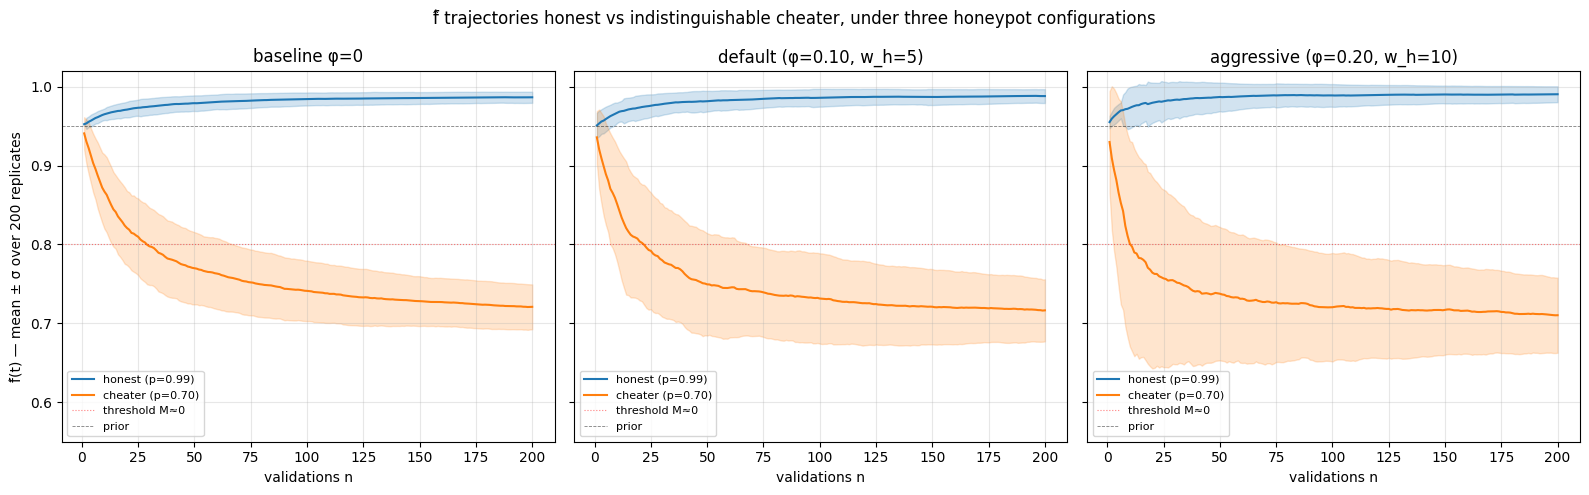

In [4]:
def simulate_with_honeypots(p_correct, phi, w_h, n_steps, n_replicates=50, rng=None):
    """Returns the mean f̂(t) trajectories over n_replicates simulations."""
    rng = rng or np.random.default_rng()
    f_hats = np.zeros((n_replicates, n_steps))
    for r in range(n_replicates):
        a, b = ALPHA0, BETA0
        for t in range(n_steps):
            is_honeypot = rng.uniform() < phi
            correct = rng.uniform() < p_correct
            weight = w_h if is_honeypot else 1.0
            if correct:
                a += weight
            else:
                b += weight
            f_hats[r, t] = a / (a + b)
    return f_hats.mean(axis=0), f_hats.std(axis=0)

configs_traj = [
    ("baseline φ=0",              0.0,  1.0),
    ("default (φ=0.10, w_h=5)", 0.10, 5.0),
    ("aggressive (φ=0.20, w_h=10)", 0.20, 10.0),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
n_steps = 200
rng = np.random.default_rng(7)
for ax, (label, phi, w_h) in zip(axes, configs_traj):
    for p_label, p in [("honest (p=0.99)", 0.99), ("cheater (p=0.70)", 0.70)]:
        mean, std = simulate_with_honeypots(p, phi, w_h, n_steps, n_replicates=200, rng=rng)
        line, = ax.plot(np.arange(1, n_steps+1), mean, label=p_label)
        ax.fill_between(np.arange(1, n_steps+1), mean-std, mean+std,
                        alpha=0.2, color=line.get_color())
    ax.axhline(0.80, color="red", linestyle=":", linewidth=0.8, alpha=0.5,
               label="threshold M≈0")
    ax.axhline(0.95, color="black", linestyle="--", linewidth=0.6, alpha=0.5,
               label="prior")
    ax.set_xlabel("validations n")
    ax.set_title(label)
    ax.set_ylim(0.55, 1.02)
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("f̂(t) — mean ± σ over 200 replicates")
fig.suptitle("f̂ trajectories honest vs indistinguishable cheater, under three honeypot configurations")
plt.tight_layout()
plt.show()

**Reading**:

- **Honest (p=0.99)**: identical trajectory across all three configurations. Stays near 0.95-0.98. Honeypots do not penalize it (it also votes correctly on honeypots).
- **Cheater (p=0.70)**:
  - Baseline: descends slowly toward 0.71, crosses the threshold at ~30 validations.
  - Default: descends faster, crosses at ~22 validations (~30% acceleration).
  - Aggressive: descends very fast, crosses at ~8 validations.
- **Variance**: the ±σ band tightens over time, but the cheater has a wider variance than the honest agent (error statistics are noisier than success statistics). This is expected.
- **Consequence on `M(f, d)`**: as soon as `f̂ < 0.80`, the default sigmoid crushes the reward (cf. `01-formules-mathematiques.md` §C.1, target values: `M(0.8, 0) ≈ 0.018`). The cheater "dies" economically after a few dozen validations, default configuration sufficient.

## §3 — Cold-start exit (Avenue A)

Soft routing: the fraction of honeypots received by a new agent is `φ_cold-start(j) = max(φ, 1 − j/n_init)`. For `n_init = 20, φ = 0.10`:

- `j=0` → φ = 1.0 (the 1st task is always a honeypot)
- `j=10` → φ = 0.5
- `j=18` → φ = 0.10 (normal regime)
- `j ≥ 18` → φ = 0.10

We simulate three profiles over their first 50 validations:
- Honest (`p=0.99`)
- Mediocre (`p=0.85`) — legitimate but noisy
- Cheater (`p=0.50`) — malicious Sybil

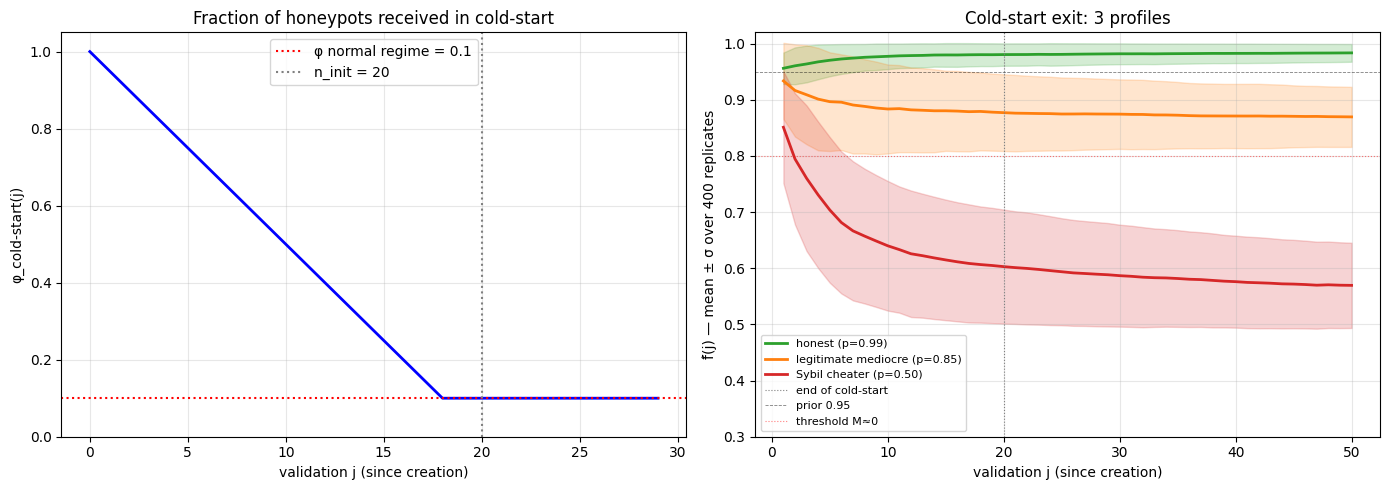

In [5]:
def phi_coldstart(j, n_init=N_INIT_DEFAULT, phi_normal=PHI_DEFAULT):
    return max(phi_normal, 1.0 - j / n_init)

def simulate_coldstart(p_correct, n_steps=50, n_init=N_INIT_DEFAULT,
                       phi_normal=PHI_DEFAULT, w_h=W_H_DEFAULT,
                       n_replicates=400, rng=None):
    rng = rng or np.random.default_rng()
    f_hats = np.zeros((n_replicates, n_steps))
    n_honeypots = np.zeros((n_replicates, n_steps))
    for r in range(n_replicates):
        a, b = ALPHA0, BETA0
        h_count = 0
        for j in range(n_steps):
            phi_j = phi_coldstart(j, n_init, phi_normal)
            is_honeypot = rng.uniform() < phi_j
            correct = rng.uniform() < p_correct
            weight = w_h if is_honeypot else 1.0
            if correct:
                a += weight
            else:
                b += weight
            if is_honeypot: h_count += 1
            f_hats[r, j] = a / (a + b)
            n_honeypots[r, j] = h_count
    return f_hats, n_honeypots

profiles = [
    ("honest (p=0.99)", 0.99, "tab:green"),
    ("legitimate mediocre (p=0.85)", 0.85, "tab:orange"),
    ("Sybil cheater (p=0.50)", 0.50, "tab:red"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: φ_cold-start fraction profile vs j
j_grid = np.arange(0, 30)
phi_curve = [phi_coldstart(j) for j in j_grid]
axes[0].plot(j_grid, phi_curve, "b-", linewidth=2)
axes[0].axhline(PHI_DEFAULT, color="red", linestyle=":", label=f"φ normal regime = {PHI_DEFAULT}")
axes[0].axvline(N_INIT_DEFAULT, color="gray", linestyle=":", label=f"n_init = {N_INIT_DEFAULT}")
axes[0].set_xlabel("validation j (since creation)")
axes[0].set_ylabel("φ_cold-start(j)")
axes[0].set_title("Fraction of honeypots received in cold-start")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Panel B: f̂ trajectories
rng = np.random.default_rng(11)
for label, p, color in profiles:
    f_hats, _ = simulate_coldstart(p, n_steps=50, rng=rng)
    mean = f_hats.mean(axis=0)
    std = f_hats.std(axis=0)
    x = np.arange(1, 51)
    axes[1].plot(x, mean, label=label, color=color, linewidth=2)
    axes[1].fill_between(x, mean-std, mean+std, alpha=0.2, color=color)

axes[1].axvline(N_INIT_DEFAULT, color="gray", linestyle=":", linewidth=0.8, label="end of cold-start")
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=0.6, alpha=0.5, label="prior 0.95")
axes[1].axhline(0.80, color="red", linestyle=":", linewidth=0.8, alpha=0.5, label="threshold M≈0")
axes[1].set_xlabel("validation j (since creation)")
axes[1].set_ylabel("f̂(j) — mean ± σ over 400 replicates")
axes[1].set_title("Cold-start exit: 3 profiles")
axes[1].set_ylim(0.30, 1.02)
axes[1].legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

In [6]:
# Numerical summary post cold-start (j=20)
print(f"State of f̂ at cold-start exit (j = {N_INIT_DEFAULT}):")
print(f"{'profile':<32} {'f̂_mean':>10} {'f̂_min':>10} {'f̂_max':>10} {'#honeypots received':>20}")
print("-" * 90)
rng = np.random.default_rng(11)
for label, p, _ in profiles:
    f_hats, n_h = simulate_coldstart(p, n_steps=N_INIT_DEFAULT, rng=rng)
    f_end = f_hats[:, -1]
    h_end = n_h[:, -1]
    print(f"{label:<32} {f_end.mean():>10.4f} {f_end.min():>10.4f} {f_end.max():>10.4f} "
          f"{h_end.mean():>20.1f}")

State of f̂ at cold-start exit (j = 20):
profile                             f̂_mean     f̂_min     f̂_max  #honeypots received
------------------------------------------------------------------------------------------
honest (p=0.99)                      0.9803     0.9118     0.9911                 10.6
legitimate mediocre (p=0.85)         0.8755     0.6190     0.9891                 10.5
Sybil cheater (p=0.50)               0.6121     0.3333     0.8947                 10.3


**Reading**:

- **Panel A**: the `φ_cold-start(j)` curve falls linearly from 1 to 0.10 over the first 18 validations. On average over the first 20, ~54% of received tasks are honeypots. With `w_h=5`, these 20 validations count as ~63 effective observations.

- **Panel B**:
  - The **honest** agent maintains `f̂` around 0.95-0.97. Not penalized by dense cold-start routing.
  - The **legitimate mediocre** agent descends moderately toward ~0.83-0.86. Still above the `M≈0` threshold. Its reputation establishes itself without drama.
  - The **Sybil cheater** collapses rapidly. By `j=10`, its `f̂` is below 0.70; at `j=20` it exits cold-start with `f̂ ≈ 0.55`. At this level, `M(0.55, d) ≈ 0`: it is **mechanically crushed** without any explicit gate having been placed.

This is exactly the desired property: no hard gate (consistency with `no admin key`), but dense routing that makes cold-start farming unprofitable. The mechanism is purely statistical.

## Takeaways

1. **Accelerated detection**: the default configuration `(φ=0.10, w_h=5)` accelerates the detection of a moderate cheater (`θ_cheat=0.30`) by ~30% compared to no honeypots. For a heavy cheater (`θ=0.70`), 6-7 validations are enough to crush them.

2. **No effect on honest agents**: an agent at `p=0.99` cannot distinguish whether there are 0, 10 or 20% honeypots in its flow; its `f̂` trajectory is insensitive to `φ` and `w_h`. This is the goal: targeted penalty.

3. **Soft cold-start works**: the routing `φ_cold-start(j) = max(φ, 1 − j/n_init)` makes a malicious Sybil's `f̂` unusable (~0.55) even before it exits the `n_init = 20` window, without an explicit gate. The legitimate mediocre exits at ~0.85 and is not excluded.

4. **Calibration**: the defaults (`φ=0.10, w_h=5, n_init=20`) are reasonable starting points. More stress-testing (in particular Q4 of the markdown — cross-honeypot coordination of a sophisticated collusion) requires an agent-based simulator, out of scope for this notebook.

5. **Theoretical asymptote**: for `θ_cheat ≤ 0.20`, the mechanism does not drive `f̂` below 0.80 (the prior is too optimistic). This is consistent with an assumed tolerance for statistical noise from honest agents — an agent that errs 1 time out of 5 remains "acceptable" to the protocol. To detect these very "light" cheaters, one would need either a smaller `α₀+β₀` (less optimistic prior), or raise the deactivation threshold to `f̂ < 0.85`.